Feature count: 245
Data shape: (24048, 253)


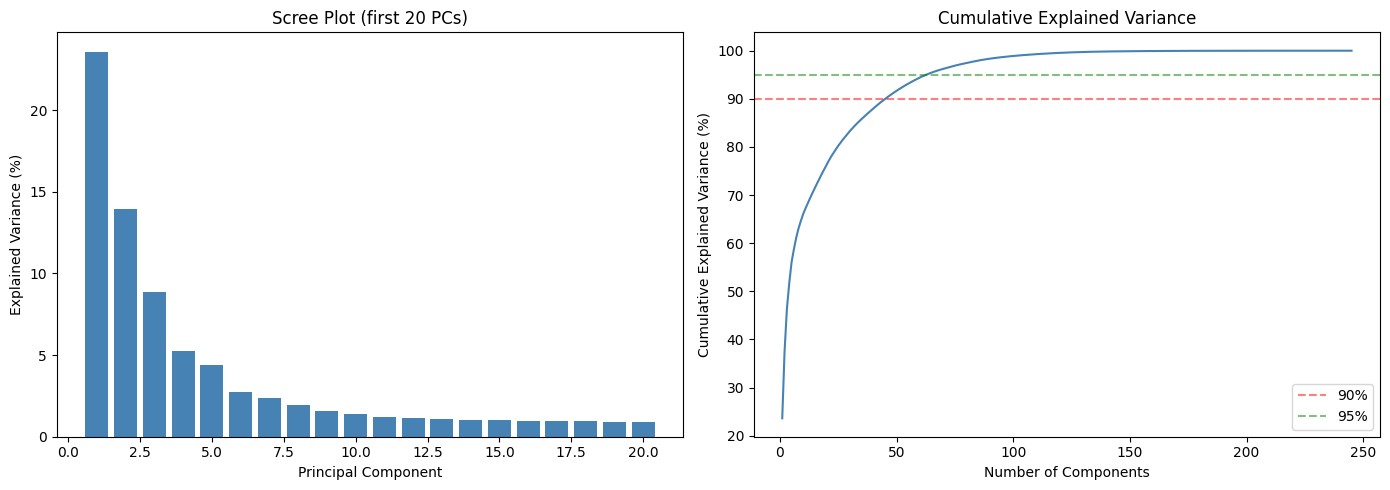

PCs to explain 90% variance: 46
PCs to explain 95% variance: 63


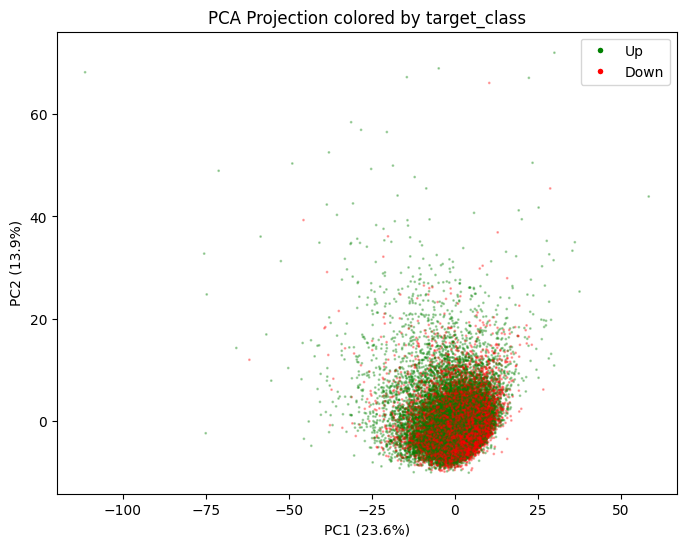

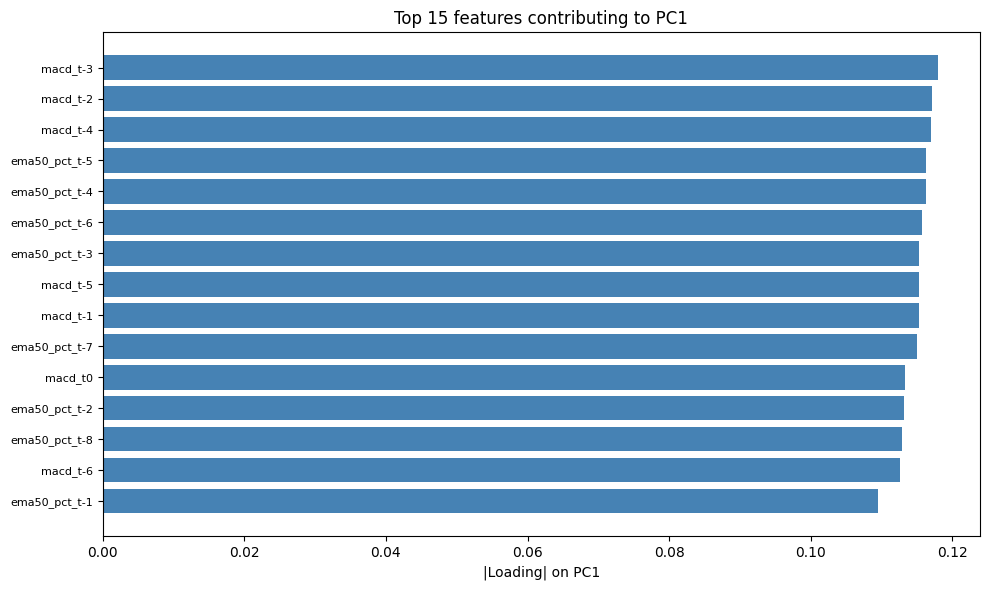

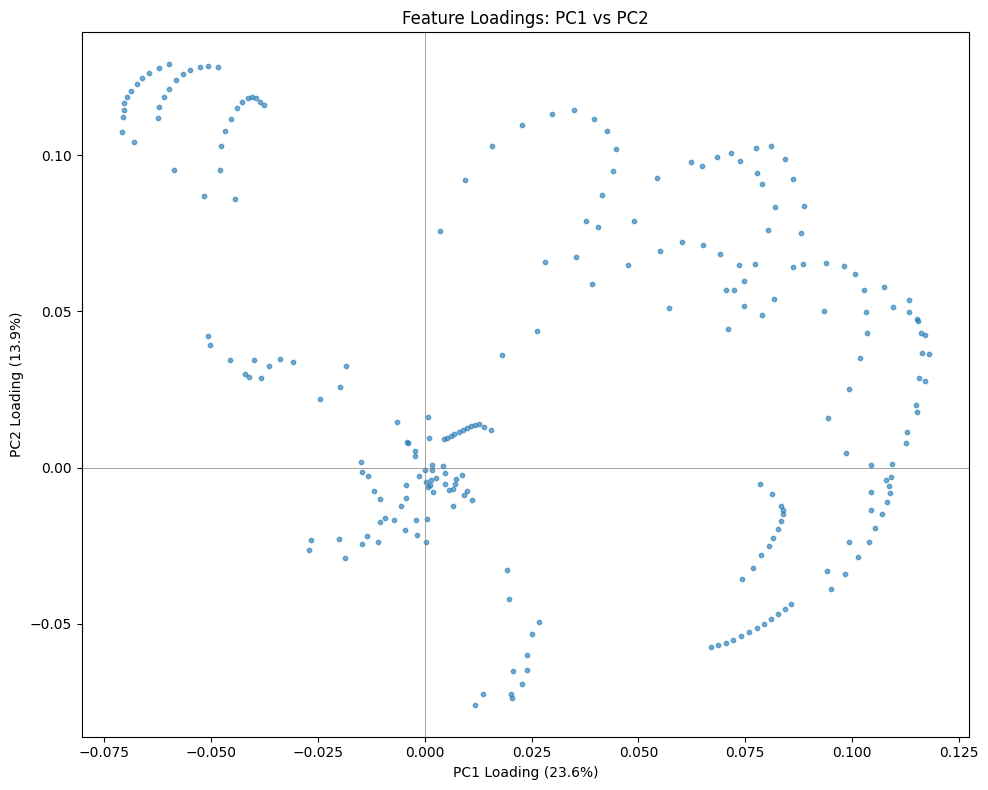

In [2]:
# ---- PCA on PEAD feature set ----
import polars as pl
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from matplotlib.lines import Line2D

# Load data
tech_path = "../data/model_staging/tech_modeling_table.parquet"
df_tech = pl.read_parquet(tech_path)

fund_path = "../data/model_staging/fundamentalIndicators/modeling_fundamentals.parquet"
df_fund = pl.read_parquet(fund_path).select([
    "symbol", pl.col("reportedDate").alias("earnings_date"),
    "eps_growth_qoq", "revenue_growth_qoq",
    "gross_margin", "gross_margin_qoq",
    "debt_to_equity", "debt_to_equity_qoq",
    "fcf_margin", "fcf_margin_qoq",
    "roe", "roe_qoq"
])

df_finbert = pl.read_parquet("../data/model_staging/finbert_tx_agg_weighted.parquet").select([
    pl.col("symbol"), pl.col("reportedDate").alias("earnings_date"),
    "pos_prob", "neg_prob"
])

df_nz = pl.read_parquet("../data/model_staging/nz_sentiment.parquet").select([
    pl.col("symbol"), pl.col("reportedDate").alias("earnings_date"),
    "overall_sentiment_score_pre", "ticker_sentiment_score_pre",
    "overall_sentiment_score_post", "ticker_sentiment_score_post",
])

df_model = df_tech.join(df_fund, on=["symbol", "earnings_date"], how="left")
df_model = df_model.join(df_finbert, on=["symbol", "earnings_date"], how="left", suffix="_fb")
df_model = df_model.join(df_nz, on=["symbol", "earnings_date"], how="left", suffix="_nz")

df_sector_raw = pl.read_parquet("../data/model_staging/finbert_tx_agg_weighted.parquet")
df_sector = df_sector_raw.select(["symbol", "sector"]).unique()
df_sector = df_sector.with_columns(pl.col("sector").fill_null("Unknown"))
sectors = sorted(df_sector["sector"].unique().to_list())
df_sector = df_sector.with_columns([
    (pl.col("sector") == s).cast(pl.Int8).alias(f"sector_{s.replace(' ', '_')}")
    for s in sectors
]).drop("sector")
df_model = df_model.join(df_sector, on="symbol", how="left")

feature_cols = [c for c in df_model.columns
                if c not in ["symbol", "earnings_date", "target_return",
                "entry_price", "target_class", "max_high",
                "min_high", "max_day", "min_day"]]
print(f"Feature count: {len(feature_cols)}")
print(f"Data shape: {df_model.shape}")

# Build flat feature matrix, impute, standardize
target = df_model["target_direction"].to_numpy()
X_all = df_model.select(feature_cols).to_numpy().astype(np.float32)
X_all = np.where(np.isinf(X_all), np.nan, X_all)
imputer = SimpleImputer(strategy="median")
X_all = imputer.fit_transform(X_all)
scaler = StandardScaler()
X_all = scaler.fit_transform(X_all)

pca = PCA()
X_pca = pca.fit_transform(X_all)

# ---- Scree plot + cumulative variance ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
evr = pca.explained_variance_ratio_
cumsum = np.cumsum(evr)

axes[0].bar(range(1, 21), evr[:20] * 100, color='steelblue')
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_title("Scree Plot (first 20 PCs)")

axes[1].plot(range(1, len(cumsum) + 1), cumsum * 100, color='steelblue')
axes[1].axhline(90, color='r', ls='--', alpha=0.5, label='90%')
axes[1].axhline(95, color='g', ls='--', alpha=0.5, label='95%')
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance (%)")
axes[1].set_title("Cumulative Explained Variance")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"PCs to explain 90% variance: {(cumsum < 0.90).sum() + 1}")
print(f"PCs to explain 95% variance: {(cumsum < 0.95).sum() + 1}")

# ---- 2D projection colored by target_class ----
colors = np.where(target == 1, 'green', 'red')
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.3, s=1)
ax.set_xlabel(f"PC1 ({evr[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({evr[1]*100:.1f}%)")
ax.set_title("PCA Projection colored by target_class")
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=5, label='Up'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=5, label='Down'),
]
ax.legend(handles=legend_elements)
plt.show()

# ---- Loading analysis for PC1 ----
loadings = pca.components_.T
pc1_loadings = np.abs(loadings[:, 0])
top_idx = np.argsort(pc1_loadings)[-15:]
top_features = [feature_cols[i] for i in top_idx]
top_values = pc1_loadings[top_idx]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(top_idx)), top_values, color='steelblue')
ax.set_yticks(range(len(top_idx)))
ax.set_yticklabels(top_features, fontsize=8)
ax.set_xlabel("|Loading| on PC1")
ax.set_title("Top 15 features contributing to PC1")
plt.tight_layout()
plt.show()

# ---- PC1 vs PC2 loadings scatter ----
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(loadings[:, 0], loadings[:, 1], alpha=0.6, s=10)
for i in range(len(loadings)):
    l1, l2 = abs(loadings[i, 0]), abs(loadings[i, 1])
    if l1 > 0.25 or l2 > 0.25:
        ax.annotate(feature_cols[i], (loadings[i, 0], loadings[i, 1]), fontsize=6, alpha=0.7)
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel(f"PC1 Loading ({evr[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 Loading ({evr[1]*100:.1f}%)")
ax.set_title("Feature Loadings: PC1 vs PC2")
plt.tight_layout()
plt.show()